## **Connect Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Import Libraries**

In [ ]:
!pip install transformers datasets seqeval optuna pytorch-crf -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 27.9 MB/s eta 0:00:00


In [ ]:
import os, json, gc, re, warnings
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna
from optuna.samplers import TPESampler
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    BloomPreTrainedModel,
    BloomModel,
    BloomConfig,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from seqeval.metrics import (
    f1_score        as seqeval_f1,
    precision_score as seqeval_precision,
    recall_score    as seqeval_recall,
)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchcrf import CRF

warnings.filterwarnings('ignore')

if not hasattr(sys.modules['__main__'], '__file__'):
    _dummy = '/content/colab_nb04v2.py'
    with open(_dummy, 'w') as _f:
        _f.write('# dummy\n')
    sys.modules['__main__'].__file__ = _dummy
    print(f"✅ __file__ set to {_dummy}")

print("✅ Semua library berhasil diimport.")
print(f"   PyTorch  : {torch.__version__}")
print(f"   Optuna   : {optuna.__version__}")

✅ __file__ set to /content/colab_nb04v2.py
✅ Semua library berhasil diimport.
   PyTorch  : 2.10.0+cu128
   Optuna   : 4.8.0


## **Setup: Paths, Constants, AMP**

In [ ]:
BASE_DIR         = '/content/drive/MyDrive/Colab Datasets'
BIO_DIR          = f'{BASE_DIR}/BIO Splits v2'
CKPT_DIR         = f'{BASE_DIR}/Checkpoints v2'
RESULT_DIR       = f'{BASE_DIR}/Results v2'
MODEL_NAME       = 'bigscience/bloom-560m'
LOCAL_BLOOM_PATH = f'{BASE_DIR}/bloom-560m-local'
MAX_LENGTH       = 512
IGNORE_IDX       = -100
DEVICE           = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

USE_AMP   = (DEVICE.type == 'cuda')
AMP_DTYPE = (
    torch.bfloat16
    if DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported()
    else torch.float16
)

N_TRIALS = 20

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,   exist_ok=True)

print(f"Device    : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"AMP       : {USE_AMP}  (dtype={AMP_DTYPE})")
print(f"BIO_DIR   : {BIO_DIR}")
print(f"RESULT_DIR: {RESULT_DIR}")

Device    : cuda
GPU       : NVIDIA A100-SXM4-40GB
VRAM      : 42.4 GB
AMP       : True  (dtype=torch.bfloat16)
BIO_DIR   : /content/drive/MyDrive/Colab Datasets/BIO Splits v2
RESULT_DIR: /content/drive/MyDrive/Colab Datasets/Results v2


## **Load Tokenizer BLOOM**

In [ ]:
import os, json
from transformers import AutoTokenizer

_tok_config_path = os.path.join(LOCAL_BLOOM_PATH, 'tokenizer.json')
_tok_cfg_path    = os.path.join(LOCAL_BLOOM_PATH, 'tokenizer_config.json')
_model_cfg_path  = os.path.join(LOCAL_BLOOM_PATH, 'config.json')

if not os.path.exists(_model_cfg_path):
    with open(_model_cfg_path, 'w') as f:
        json.dump({"model_type": "bloom"}, f, indent=2)
    print('✅ Stub config.json dibuat.')

if os.path.exists(_tok_config_path):
    try:
        tokenizer = AutoTokenizer.from_pretrained(LOCAL_BLOOM_PATH)
        print(f'✅ Tokenizer dimuat dari lokal: {LOCAL_BLOOM_PATH}')
    except Exception as e:
        print(f'⚠️  Gagal load lokal ({e})\n   → Fallback ke HuggingFace...')
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        tokenizer.save_pretrained(LOCAL_BLOOM_PATH)
        print(f'✅ Tokenizer dari HF, disimpan ulang ke: {LOCAL_BLOOM_PATH}')
else:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    tokenizer.save_pretrained(LOCAL_BLOOM_PATH)
    print(f'✅ Tokenizer dimuat dari HuggingFace: {MODEL_NAME}')

tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'right'

print(f'   Vocab size  : {tokenizer.vocab_size:,}')
print(f'   Pad token   : {tokenizer.pad_token!r}  (id={tokenizer.pad_token_id})')
print(f'   Padding side: {tokenizer.padding_side}')

✅ Tokenizer dimuat dari lokal: /content/drive/MyDrive/Colab Datasets/bloom-560m-local
   Vocab size  : 250,680
   Pad token   : '</s>'  (id=2)
   Padding side: right


## **Cache BLOOM Backbone to Drive**

In [ ]:
_has_config = os.path.exists(os.path.join(LOCAL_BLOOM_PATH, 'config.json'))
_has_bin    = os.path.exists(os.path.join(LOCAL_BLOOM_PATH, 'pytorch_model.bin'))
_has_safe   = (
    os.path.isdir(LOCAL_BLOOM_PATH) and
    any(f.endswith('.safetensors') for f in os.listdir(LOCAL_BLOOM_PATH))
)
_bloom_model_ready = _has_config and (_has_bin or _has_safe)

if not _bloom_model_ready:
    print(f"Caching BLOOM backbone ke Drive (~1.1 GB, hanya sekali)...")
    from transformers import BloomModel as _BloomTemp
    _tmp = _BloomTemp.from_pretrained(MODEL_NAME)
    _tmp.save_pretrained(LOCAL_BLOOM_PATH)
    del _tmp
    torch.cuda.empty_cache()
    print(f"✅ Cache tersimpan: {LOCAL_BLOOM_PATH}")
else:
    print(f"✅ Cache sudah ada (config + weights): {LOCAL_BLOOM_PATH}")

✅ Cache sudah ada (config + weights): /content/drive/MyDrive/Colab Datasets/bloom-560m-local


## **Define `BloomForMTL_v2`**

In [ ]:
class BloomForMTL_v2(BloomPreTrainedModel):
    def __init__(self, config,
                 num_sentence_labels: int   = 2,
                 num_token_labels:    int   = 3,
                 dropout:             float = 0.1,
                 alpha:               float = 0.5,
                 beta:                float = 0.5,
                 label_smoothing:     float = 0.1,
                 use_crf:             bool  = True,
                 gamma:               float = 0.0):
        super().__init__(config)
        self.bloom           = BloomModel(config)
        self.alpha           = alpha
        self.beta            = beta
        self.label_smoothing = label_smoothing
        self.use_crf         = use_crf
        self.gamma           = gamma
        self._token_class_weights = None
        self.dropout         = nn.Dropout(dropout)

        h = config.hidden_size
        self.sentence_classifier = nn.Linear(h, num_sentence_labels)
        self.token_classifier    = nn.Linear(h, num_token_labels)

        if self.use_crf:
            self.crf = CRF(num_token_labels, batch_first=True)

        self.post_init()

    @classmethod
    def _can_set_experts_implementation(cls) -> bool:
        return False

    def forward(self, input_ids, attention_mask,
                sentence_labels=None, token_labels=None, **kwargs):

        out    = self.bloom(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state  # (B, T, H)

        # Sentence Head: Masked Mean Pooling
        mask_e = attention_mask.unsqueeze(-1).float()
        pooled = self.dropout(
            (hidden * mask_e).sum(1) / mask_e.sum(1).clamp(min=1e-9)
        )
        sentence_logits = self.sentence_classifier(pooled)  # (B, 2)

        # Token Head: CRF Emissions
        token_emissions = self.token_classifier(self.dropout(hidden))  # (B, T, 3)

        loss         = None
        crf_loss     = None
        l_sent       = None
        aux_tok_loss = None  # ← NEW

        if sentence_labels is not None:
            l_sent = F.cross_entropy(
                sentence_logits, sentence_labels,
                label_smoothing=self.label_smoothing
            )

            if self.beta > 0.0 and token_labels is not None and self.use_crf:
                crf_mask   = attention_mask.bool()
                crf_labels = token_labels.clone()
                crf_labels[crf_labels == IGNORE_IDX] = 0
                crf_loss = -self.crf(
                    token_emissions.float(),
                    crf_labels,
                    mask=crf_mask, reduction="mean"
                )

                # ── Auxiliary Weighted Token CE (gamma > 0 aktifkan) ──────────
                # Atasi class imbalance O:B-TOX:I-TOX ≈ 95:3:2
                # gamma=0.0 (default) → tidak berpengaruh, backward-compatible
                if self.gamma > 0.0 and token_labels is not None:
                    valid_mask = (token_labels != IGNORE_IDX)
                    if valid_mask.any():
                        w = self._token_class_weights
                        if w is not None:
                            w = w.to(token_emissions.device)
                        aux_tok_loss = F.cross_entropy(
                            token_emissions.float()[valid_mask],
                            token_labels[valid_mask],
                            weight=w,
                            reduction="mean"
                        )
                        loss = (self.alpha * l_sent
                                + self.beta  * crf_loss
                                + self.gamma * aux_tok_loss)
                    else:
                        loss = self.alpha * l_sent + self.beta * crf_loss
                else:
                    loss = self.alpha * l_sent + self.beta * crf_loss
            else:
                loss = self.alpha * l_sent

        # Inference: CRF Viterbi Decoding
        if self.use_crf and not self.training:
            token_preds_viterbi = self.crf.decode(
                token_emissions.float(), mask=attention_mask.bool()
            )
        elif self.use_crf and self.training:
            token_preds_viterbi = None
        else:
            if not self.training:
                token_preds_viterbi = token_emissions.argmax(-1).cpu().tolist()
            else:
                token_preds_viterbi = None

        return {
            "loss"           : loss,
            "sent_loss"      : l_sent,
            "crf_loss"       : crf_loss,
            "aux_tok_loss"   : aux_tok_loss,
            "sentence_logits": sentence_logits,
            "token_logits"   : token_emissions,
            "token_preds_crf": token_preds_viterbi
        }

print("✅ BloomForMTL_v2 (Main — gamma + aux_tok_loss + beta_ramp ready) defined")

✅ BloomForMTL_v2 (Main — gamma + aux_tok_loss + beta_ramp ready) defined


## **Define `HateSpeechMTLDataset`**

In [ ]:
class HateSpeechMTLDataset(torch.utils.data.Dataset):
    def __init__(self, csv_path: str, use_precomputed: bool = True):
        df = pd.read_csv(csv_path)
        self.texts           = df["text"].tolist()
        self.sentence_labels = df["label"].tolist()
        self.token_labels    = [json.loads(b) for b in df["bio_labels"].tolist()]
        self.languages       = df["language"].tolist()
        self.has_slang  = df.get("has_slang",  pd.Series([0] * len(df))).tolist()
        self.has_abbrev = df.get("has_abbrev", pd.Series([0] * len(df))).tolist()

        self.use_precomputed = use_precomputed

        if use_precomputed:
            split_name = os.path.basename(csv_path).replace("_bio.csv", "")
            # Path .npy WAJIB dari BIO Splits v2 (sudah diatur di BIO_DIR)
            ids_path   = f"{BIO_DIR}/{split_name}_input_ids.npy"
            mask_path  = f"{BIO_DIR}/{split_name}_attn_mask.npy"

            if os.path.exists(ids_path) and os.path.exists(mask_path):
                self.input_ids_arr      = np.load(ids_path,  mmap_mode="r")
                self.attention_mask_arr = np.load(mask_path, mmap_mode="r")
                print(
                    f"✅ [{split_name}] Pre-tokenized arrays loaded: "
                    f"{self.input_ids_arr.shape}  (dtype={self.input_ids_arr.dtype})"
                )
            else:
                print(
                    f"⚠️  .npy tidak ditemukan di {BIO_DIR}.\n"
                    f"   Fallback ke on-the-fly tokenization.\n"
                    f"   → Pastikan NB02v2 (precompute_tokens) sudah dijalankan."
                )
                self.use_precomputed = False

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        if self.use_precomputed:
            input_ids      = torch.tensor(
                self.input_ids_arr[idx].astype(np.int64), dtype=torch.long
            )
            attention_mask = torch.tensor(
                self.attention_mask_arr[idx].astype(np.int64), dtype=torch.long
            )
        else:
            text_norm = re.sub(r"\s+", " ", str(self.texts[idx])).strip()
            enc = tokenizer(
                text_norm,
                padding="max_length",
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )
            input_ids      = enc["input_ids"].squeeze(0)
            attention_mask = enc["attention_mask"].squeeze(0)

        # Pad/truncate token_labels ke MAX_LENGTH (identik NB03)
        tok = self.token_labels[idx][:MAX_LENGTH]
        pad_len = MAX_LENGTH - len(tok)
        if pad_len > 0:
            tok = tok + [-100] * pad_len   # IGNORE_IDX = -100

        return {
            "input_ids"      : input_ids,
            "attention_mask" : attention_mask,
            "sentence_label" : torch.tensor(self.sentence_labels[idx], dtype=torch.long),
            "token_labels"   : torch.tensor(tok, dtype=torch.long),
            "language"       : self.languages[idx],
        }


print("✅ HateSpeechMTLDataset (identik NB03v2, path → BIO Splits v2) defined.")

✅ HateSpeechMTLDataset (identik NB03v2, path → BIO Splits v2) defined.


## **File Verification (`BIO Splits v2`)**

In [ ]:
print("=" * 60)
print("  PENGECEKAN FILE PREREQUISITE NB04v2")
print("=" * 60)

all_ok = True

# 1. BLOOM cache
print("\n📦 BLOOM Cache:")
bloom_ok = os.path.exists(LOCAL_BLOOM_PATH)
print(f'  {"✅" if bloom_ok else "❌"} {LOCAL_BLOOM_PATH}')
if not bloom_ok:
    all_ok = False
    print("     → Jalankan cell Cache BLOOM dulu (cell 5b).")

# 2. BIO CSV dari BIO Splits v2
print("\n📄 BIO CSV Splits (dari BIO Splits v2):")
for split in ["train", "val", "test"]:
    path   = f"{BIO_DIR}/{split}_bio.csv"
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1024 / 1024 if exists else 0
    print(f'  {"✅" if exists else "❌"} {split}_bio.csv  {"(" + f"{size:.1f} MB)" if exists else "— TIDAK ADA"}')
    if not exists:
        all_ok = False
print("     → Jika tidak ada, jalankan NB02v2 terlebih dahulu.")

# 3. Pre-tokenized .npy dari BIO Splits v2
print("\n⚡ Pre-tokenized .npy Arrays (dari BIO Splits v2):")
for split in ["train", "val"]:          # test tidak wajib untuk Optuna
    for suffix in ["input_ids", "attn_mask"]:
        path   = f"{BIO_DIR}/{split}_{suffix}.npy"
        exists = os.path.exists(path)
        size   = os.path.getsize(path) / 1024 / 1024 if exists else 0
        print(f'  {"✅" if exists else "⚠️ "} {split}_{suffix}.npy  {"(" + f"{size:.1f} MB)" if exists else "— fallback ke on-the-fly"}')

# 4. Results v2 folder
print("\n📂 Output Folder:")
print(f'  {"✅" if os.path.exists(RESULT_DIR) else "○ (dibuat otomatis)"} {RESULT_DIR}')

print()
print("=" * 60)
if all_ok:
    print("✅ Semua prerequisite siap. Lanjut ke training Optuna.")
else:
    print("❌ Ada file yang kurang — selesaikan dulu sebelum lanjut.")
print("=" * 60)

  PENGECEKAN FILE PREREQUISITE NB04v2

📦 BLOOM Cache:
  ✅ /content/drive/MyDrive/Colab Datasets/bloom-560m-local

📄 BIO CSV Splits (dari BIO Splits v2):
  ✅ train_bio.csv  (85.2 MB)
  ✅ val_bio.csv  (18.3 MB)
  ✅ test_bio.csv  (18.3 MB)
     → Jika tidak ada, jalankan NB02v2 terlebih dahulu.

⚡ Pre-tokenized .npy Arrays (dari BIO Splits v2):
  ✅ train_input_ids.npy  (54.7 MB)
  ✅ train_attn_mask.npy  (54.7 MB)
  ✅ val_input_ids.npy  (11.7 MB)
  ✅ val_attn_mask.npy  (11.7 MB)

📂 Output Folder:
  ✅ /content/drive/MyDrive/Colab Datasets/Results v2

✅ Semua prerequisite siap. Lanjut ke training Optuna.


## **Load Dataset from `BIO Splits v2`**

In [ ]:
train_dataset = HateSpeechMTLDataset(f"{BIO_DIR}/train_bio.csv")
val_dataset   = HateSpeechMTLDataset(f"{BIO_DIR}/val_bio.csv")

print(f"\nDataset summary:")
print(f"  Train : {len(train_dataset):,} samples")
print(f"  Val   : {len(val_dataset):,} samples")
print(f"  BIO_DIR: {BIO_DIR}")

✅ [train] Pre-tokenized arrays loaded: (28000, 512)  (dtype=int32)
✅ [val] Pre-tokenized arrays loaded: (6000, 512)  (dtype=int32)

Dataset summary:
  Train : 28,000 samples
  Val   : 6,000 samples
  BIO_DIR: /content/drive/MyDrive/Colab Datasets/BIO Splits v2


## **Define `objective(trial)`**

In [ ]:
def _compute_token_class_weights(dataset, n_classes=3, smoothing=0.1):
    counts = {i: 0 for i in range(n_classes)}
    for bio_seq in dataset.token_labels:
        for lbl in bio_seq:
            if isinstance(lbl, (int, np.integer)) and 0 <= int(lbl) < n_classes:
                counts[int(lbl)] += 1
    total   = sum(counts.values()) + smoothing * n_classes
    weights = torch.tensor(
        [total / (n_classes * (counts[i] + smoothing)) for i in range(n_classes)],
        dtype=torch.float32
    )
    weights = weights / weights.min()
    weights = weights.clamp(max=10.0)
    print(f"Token class weights: O={weights[0]:.3f}  B-TOX={weights[1]:.3f}  I-TOX={weights[2]:.3f}")
    print(f"  Counts: O={counts[0]:,}  B-TOX={counts[1]:,}  I-TOX={counts[2]:,}")
    return weights

GLOBAL_TOKEN_CLASS_WEIGHTS = _compute_token_class_weights(train_dataset)
print(f"✅ GLOBAL_TOKEN_CLASS_WEIGHTS computed once, reused di semua {N_TRIALS} trials.")

Token class weights: O=1.000  B-TOX=6.422  I-TOX=10.000
  Counts: O=223,258  B-TOX=34,767  I-TOX=13,180
✅ GLOBAL_TOKEN_CLASS_WEIGHTS computed once, reused di semua 20 trials.


In [ ]:
def objective(trial: optuna.Trial) -> float:
    torch.cuda.empty_cache()
    gc.collect()

    # ── Search space ──────────
    lr = trial.suggest_float("lr", 8e-6, 2e-5, log=True)
    alpha = trial.suggest_categorical("alpha", [0.7, 0.8, 0.9])
    beta = trial.suggest_categorical("beta", [0.1, 0.2, 0.3])
    gamma = trial.suggest_categorical("gamma", [0.0, 0.05, 0.10, 0.15])
    dropout = trial.suggest_categorical("dropout", [0.15, 0.20, 0.25])

    # ── Fixed params (tidak perlu di-tune) ──────────────────────────────────
    warmup_steps = 1000
    label_smoothing = 0.10
    epochs          = 4
    batch_size      = 16
    weight_decay    = 0.01

    print(f"\n{'='*65}")
    print(f"  START TRIAL #{trial.number}")
    print(f"{'='*65}")
    print(f"  alpha={alpha}  beta={beta}  dropout={dropout}  lr={lr:.2e}")
    print(f"  label_smoothing={label_smoothing}  use_crf=True")
    print(f"  warmup_steps={warmup_steps}  weight_decay={weight_decay}")
    print(f"  epochs={epochs} (fixed)  batch_size={batch_size} (fixed)")
    print(f"  [Beta ramp aktif: epoch-0 pakai beta×0.2={beta*0.2:.3f}]")
    print(f"{'='*65}\n")

    model = optimizer = scheduler = train_loader = val_loader = scaler = None

    try:
        config = BloomConfig.from_pretrained(LOCAL_BLOOM_PATH)
        model  = BloomForMTL_v2(
            config,
            num_sentence_labels = 2,
            num_token_labels    = 3,
            dropout             = dropout,
            alpha               = alpha,
            beta                = beta,
            label_smoothing     = label_smoothing,
            use_crf             = True,
            gamma               = gamma,
        ).to(DEVICE)
        _w = GLOBAL_TOKEN_CLASS_WEIGHTS.to(DEVICE)
        model._token_class_weights = _w
        from transformers import BloomModel as _BM
        _pretrained = _BM.from_pretrained(LOCAL_BLOOM_PATH)
        model.bloom.load_state_dict(_pretrained.state_dict())
        del _pretrained
        torch.cuda.empty_cache()

        model.bloom.gradient_checkpointing_enable(
            gradient_checkpointing_kwargs={"use_reentrant": False}
        )
        model.config.use_cache = False

        # Differential LR: CRF = 10× backbone (identik NB03 main model)
        optimizer = torch.optim.AdamW([
            {'params': [p for n, p in model.named_parameters() if 'crf' not in n],
             'lr': lr},
            {'params': model.crf.parameters(),
             'lr': lr * 10},
        ], weight_decay=weight_decay)

        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
        val_loader = DataLoader(
            val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

        total_steps = len(train_loader) * epochs
        scheduler   = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps   = warmup_steps,
            num_training_steps = total_steps,
        )

        use_scaler = USE_AMP and (AMP_DTYPE == torch.float16)
        if DEVICE.type == 'cuda':
            try:
                scaler = torch.amp.GradScaler('cuda', enabled=use_scaler)
            except TypeError:
                scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)

        ID2LABEL_OBJ     = {0: 'O', 1: 'B-TOX', 2: 'I-TOX'}
        best_val_hm      = 0.0
        no_improve_count = 0

        for epoch in range(epochs):

            # ── BETA RAMP: epoch 0 = 20% beta target ─────────────────────
            # Mencegah CRF loss spike (15.8 di B2 epoch-1) mendominasi gradient
            current_beta = beta * 0.2 if epoch == 0 else beta
            model.beta   = current_beta

            # ── TRAINING ─────────────────────────────────────────────────
            model.train()
            total_loss = total_sent_loss = total_crf_loss = 0.0
            n_batches  = 0

            pbar = tqdm(train_loader,
                        desc=f'Trial#{trial.number} Ep{epoch+1}/{epochs} [TRAIN]',
                        leave=False)
            for batch in pbar:
                optimizer.zero_grad()

                with torch.autocast(device_type=DEVICE.type,
                                    dtype=AMP_DTYPE, enabled=USE_AMP):
                    out = model(
                        batch["input_ids"].to(DEVICE),
                        batch["attention_mask"].to(DEVICE),
                        sentence_labels = batch["sentence_label"].to(DEVICE),
                        token_labels    = batch["token_labels"].to(DEVICE),
                    )

                loss = out["loss"]
                if loss is None or torch.isnan(loss) or torch.isinf(loss):
                    optimizer.zero_grad()
                    continue

                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

                scheduler.step()
                total_loss += loss.item()
                if out.get("sent_loss") is not None:
                    total_sent_loss += out["sent_loss"].item()
                if out.get("crf_loss") is not None:
                    total_crf_loss  += out["crf_loss"].item()
                n_batches += 1
                pbar.set_postfix({'loss': f'{total_loss/max(n_batches,1):.4f}'})

            avg_loss      = total_loss      / max(n_batches, 1)
            avg_sent_loss = total_sent_loss / max(n_batches, 1)
            avg_crf_loss  = total_crf_loss  / max(n_batches, 1)

            # ── VALIDATION ───────────────────────────────────────────────
            model.eval()
            total_val_loss = 0.0
            n_val_batches  = 0

            val_probs, val_labels_list        = [], []
            all_token_preds, all_token_labels = [], []
            all_languages                     = []

            with torch.no_grad():
                for vbatch in tqdm(val_loader,
                                   desc=f'Trial#{trial.number} Ep{epoch+1}/{epochs} [VAL]',
                                   leave=False):
                    with torch.autocast(device_type=DEVICE.type,
                                        dtype=AMP_DTYPE, enabled=USE_AMP):
                        vout = model(
                            vbatch["input_ids"].to(DEVICE),
                            vbatch["attention_mask"].to(DEVICE),
                            sentence_labels = vbatch["sentence_label"].to(DEVICE),
                            token_labels    = vbatch["token_labels"].to(DEVICE),
                        )

                    if vout["loss"] is not None:
                        total_val_loss += vout["loss"].item()
                        n_val_batches  += 1

                    probs = torch.softmax(
                        vout["sentence_logits"].float(), dim=-1)[:, 1]
                    val_probs.extend(probs.cpu().tolist())
                    val_labels_list.extend(vbatch["sentence_label"].tolist())
                    all_languages.extend(
                        vbatch.get("language", ["?"] * len(vbatch["sentence_label"])))

                    preds_crf  = vout["token_preds_crf"]
                    labels_tok = vbatch["token_labels"].tolist()
                    mask_tok   = vbatch["attention_mask"].tolist()

                    for pred_seq, label_seq, mask_seq in zip(
                            preds_crf, labels_tok, mask_tok):
                        valid_indices = [i for i, m in enumerate(mask_seq) if m == 1]
                        if len(pred_seq) != len(valid_indices):
                            continue
                        p_tags, t_tags = [], []
                        for pred_val, idx in zip(pred_seq, valid_indices):
                            lbl = label_seq[idx]
                            if lbl != IGNORE_IDX:
                                p_tags.append(ID2LABEL_OBJ[pred_val])
                                t_tags.append(ID2LABEL_OBJ[lbl])
                        if p_tags:
                            all_token_preds.append(p_tags)
                            all_token_labels.append(t_tags)

            avg_val_loss = total_val_loss / max(n_val_batches, 1)

            # ── Sentence-level metrics ────────────────────────────────────
            val_probs_np = np.array(val_probs)
            best_t = max(
                np.arange(0.30, 0.90, 0.01),
                key=lambda thr: f1_score(
                    val_labels_list,
                    (val_probs_np >= thr).astype(int),
                    average="binary", zero_division=0,
                )
            )
            best_preds = (val_probs_np >= best_t).astype(int)
            sent_f1    = f1_score(
                val_labels_list, best_preds, average="binary", zero_division=0)
            val_acc    = accuracy_score(val_labels_list, best_preds)
            val_p, val_r, _, _ = precision_recall_fscore_support(
                val_labels_list, best_preds, average='binary', zero_division=0)
            try:
                val_auc = roc_auc_score(val_labels_list, val_probs_np)
            except Exception:
                val_auc = 0.0

            # ── Token-level (Span) metrics ────────────────────────────────
            span_f1 = span_p = span_r = 0.0
            if all_token_labels:
                try:
                    span_f1 = seqeval_f1(
                        all_token_labels, all_token_preds, zero_division=0)
                    span_p  = seqeval_precision(
                        all_token_labels, all_token_preds, zero_division=0)
                    span_r  = seqeval_recall(
                        all_token_labels, all_token_preds, zero_division=0)
                except TypeError:
                    span_f1 = seqeval_f1(all_token_labels, all_token_preds)
                    span_p  = seqeval_precision(all_token_labels, all_token_preds)
                    span_r  = seqeval_recall(all_token_labels, all_token_preds)

            # ── Harmonic Mean ─────────────────────────────────────────────
            harmonic = (
                2 * sent_f1 * span_f1 / (sent_f1 + span_f1)
                if (sent_f1 + span_f1) > 0 else 0.0
            )

            # ── Per-language metrics ──────────────────────────────────────
            lang_metrics = {}
            for lang in ['id', 'en', 'mixed']:
                idxs = [i for i, lg in enumerate(all_languages) if lg == lang]
                if not idxs:
                    continue
                y_true = [int(val_labels_list[i]) for i in idxs]
                y_pred = [int(best_preds[i])       for i in idxs]
                lp, lr_val, lf, _ = precision_recall_fscore_support(
                    y_true, y_pred, average='binary', zero_division=0)
                lang_metrics[lang] = {
                    'n'  : len(idxs),
                    'acc': float(accuracy_score(y_true, y_pred)),
                    'p'  : float(lp),
                    'r'  : float(lr_val),
                    'f1' : float(lf),
                }

            # ── Update best & early stopping counter ──────────────────────
            prev_best   = best_val_hm
            best_val_hm = max(best_val_hm, harmonic)
            if harmonic > prev_best + 0.003:
                no_improve_count = 0
            else:
                no_improve_count += 1
            _es_display = no_improve_count

            # ── LOG — format identik B1/B2 ───────────────────────────────
            log_msg = (
                f'\n┌─ Trial #{trial.number} | Epoch {epoch+1:02d}/{epochs} {"─"*38}\n'
                f'│  [LOSS]\n'
                f'│    train_loss       = {avg_loss:.4f}\n'
                f'│    val_loss         = {avg_val_loss:.4f}\n'
                f'│    sent_loss        = {avg_sent_loss:.4f}\n'
                f'│    crf_loss         = {avg_crf_loss:.4f}'
                f'  (β_current={current_beta:.3f} / β_target={beta})\n'
                f'│\n'
                f'│  [SENTENCE-LEVEL]  (threshold={best_t:.2f})\n'
                f'│    Accuracy         = {val_acc:.4f}\n'
                f'│    Precision        = {val_p:.4f}\n'
                f'│    Recall           = {val_r:.4f}\n'
                f'│    F1               = {sent_f1:.4f}\n'
                f'│    AUC-ROC          = {val_auc:.4f}\n'
                f'│\n'
                f'│  [TOKEN-LEVEL / SPAN (seqeval)]\n'
                f'│    Span Precision   = {span_p:.4f}\n'
                f'│    Span Recall      = {span_r:.4f}\n'
                f'│    Span F1          = {span_f1:.4f}\n'
                f'│\n'
                f'│  [COMBINED]\n'
                f'│    Harmonic Mean    = {harmonic:.4f}  (F1_sent ⊕ SpanF1)\n'
                f'│    Best HM so far  = {best_val_hm:.4f}\n'
            )

            if lang_metrics:
                log_msg += f'│\n│  [PER-LANGUAGE — Sentence]\n'
                for lang, lm in lang_metrics.items():
                    log_msg += (
                        f'│    [{lang:>5}] n={lm["n"]:>5}  '
                        f'Acc={lm["acc"]:.4f}  P={lm["p"]:.4f}  '
                        f'R={lm["r"]:.4f}  F1={lm["f1"]:.4f}\n'
                    )

            log_msg += (
                f'│\n'
                f'│    label_smoothing  = {label_smoothing}\n'
                f'│    use_crf          = True\n'
                f'│    alpha            = {alpha}  beta_target={beta}\n'
                f'│    lr               = {lr:.2e}  dropout={dropout}\n'
                f'│    early_stop       = {_es_display}/2\n'
                f'└{"─"*64}'
            )
            print(log_msg)

            # ── Pruning (SEBELUM early stop break) ───────────────────────
            trial.report(harmonic, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

            # ── Early stopping ────────────────────────────────────────────
            if epoch >= 1 and no_improve_count >= 2:
                print(f"  → Early stop Trial #{trial.number} di epoch {epoch+1}")
                break

    except optuna.exceptions.TrialPruned:
        raise
    except torch.cuda.OutOfMemoryError as oom:
        print(f"⚠️  Trial {trial.number}: CUDA OOM → PRUNED.")
        raise optuna.exceptions.TrialPruned(f"CUDA OOM: {oom}")
    except Exception as e:
        import traceback
        print(f"❌ Trial {trial.number}: {type(e).__name__}: {e}")
        traceback.print_exc()
        raise optuna.exceptions.TrialPruned(f"{type(e).__name__}: {e}")
    finally:
        model = optimizer = scheduler = train_loader = val_loader = scaler = None
        gc.collect()
        torch.cuda.empty_cache()

    print(f"\n  ✅ Trial #{trial.number} COMPLETE — Best HM = {best_val_hm:.4f}")
    return best_val_hm


print("✅ objective() v2 — search space direvisi (lr [8e-6,2e-5], alpha=[0.7,0.8,0.9], beta=[0.1,0.2,0.3], gamma=[0.0,0.05,0.10,0.15], epochs=4) — defined.")

✅ objective() v2 — search space direvisi (lr [8e-6,2e-5], alpha=[0.7,0.8,0.9], beta=[0.1,0.2,0.3], gamma=[0.0,0.05,0.10,0.15], epochs=4) — defined.


## **Generate Optuna Study (`Results v2/optuna_study_v2.db`)**

In [ ]:
import os

OPTUNA_DB_PATH = f"{RESULT_DIR}/optuna_study_v2.db"

if os.path.exists(OPTUNA_DB_PATH):
    os.remove(OPTUNA_DB_PATH)
    print(f"✅ DB dihapus: {OPTUNA_DB_PATH}")
    print("   Study akan mulai fresh dari Trial #0.")
else:
    print("⚠️  DB tidak ditemukan, sudah bersih.")

✅ DB dihapus: /content/drive/MyDrive/Colab Datasets/Results v2/optuna_study_v2.db
   Study akan mulai fresh dari Trial #0.


In [ ]:
os.makedirs(RESULT_DIR, exist_ok=True)

OPTUNA_DB_PATH = f"{RESULT_DIR}/optuna_study_v2.db"

N_TRIALS = 20

study = optuna.create_study(
    direction   = "maximize",
    sampler = TPESampler(seed=42, multivariate=True, n_startup_trials=5),
    pruner      = optuna.pruners.MedianPruner(
        n_startup_trials = 5,
        n_warmup_steps   = 1,
    ),
    storage        = f"sqlite:///{OPTUNA_DB_PATH}",
    study_name     = "bloom_mtl_v2",
    load_if_exists = True,
)

completed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
pruned    = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)

print(f"Optuna study v2 siap.")
print(f"  DB path      : {OPTUNA_DB_PATH}")
print(f"  Study name   : bloom_mtl_v2")
print(f"  Direction    : maximize (Val HM F1)")
print(f"  Sampler      : TPESampler(seed=42, multivariate=True, n_startup_trials=5)")
print(f"  Pruner       : MedianPruner(n_startup=5, n_warmup=1)")
print(f"  Completed    : {completed}")
print(f"  Target trials: {N_TRIALS}")
print(f"  Pruned       : {pruned}")
if completed > 0:
    print(f"  Best so far  : {study.best_value:.4f} (Trial #{study.best_trial.number})")
else:
    print("  → Fresh study, belum ada trial COMPLETE.")
print()
print("⚠️  MONITOR compute units di Colab setiap 2-3 trial!")
print("   Jika sisa < 25 units, stop Optuna dan langsung jalankan main model")
print("   dengan best params yang sudah ada.")

[I 2026-05-10 22:25:21,410] A new study created in RDB with name: bloom_mtl_v2


Optuna study v2 siap.
  DB path      : /content/drive/MyDrive/Colab Datasets/Results v2/optuna_study_v2.db
  Study name   : bloom_mtl_v2
  Direction    : maximize (Val HM F1)
  Sampler      : TPESampler(seed=42, multivariate=True, n_startup_trials=5)
  Pruner       : MedianPruner(n_startup=5, n_warmup=1)
  Completed    : 0
  Target trials: 20
  Pruned       : 0
  → Fresh study, belum ada trial COMPLETE.

⚠️  MONITOR compute units di Colab setiap 2-3 trial!
   Jika sisa < 25 units, stop Optuna dan langsung jalankan main model
   dengan best params yang sudah ada.


## **Run `study.optimize()` (20 Trials)**

In [ ]:
import shutil

def backup_callback(study, trial):
    if trial.state == optuna.trial.TrialState.COMPLETE:
        print(
            f"  💾 Trial {trial.number} COMPLETE — "
            f"F1={trial.value:.4f} — DB saved to {OPTUNA_DB_PATH}"
        )

_completed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
_remaining = max(0, N_TRIALS - _completed)

print(f"Memulai Optuna tuning — target {N_TRIALS} trials...")
print(f"  Sudah selesai : {_completed}")
print(f"  Sisa yang perlu dijalankan: {_remaining}")
print(f"Resume otomatis jika session putus (load_if_exists=True).")
print("=" * 60)

if _remaining > 0:
    study.optimize(
        objective,
        n_trials  = _remaining,
        timeout   = None,
        callbacks = [backup_callback],
    )
else:
    print(f"✅ Study sudah mencapai {N_TRIALS} trials. Lanjut ke Cell 13.")

print("\n" + "=" * 60)
print(f"✅ Optuna selesai! {N_TRIALS} trials target tercapai.")
print(f"   DB tersimpan di: {OPTUNA_DB_PATH}")

Memulai Optuna tuning — target 20 trials...
  Sudah selesai : 0
  Sisa yang perlu dijalankan: 20
Resume otomatis jika session putus (load_if_exists=True).

  START TRIAL #0
  alpha=0.7  beta=0.1  dropout=0.15  lr=1.13e-05
  label_smoothing=0.1  use_crf=True
  warmup_steps=1000  weight_decay=0.01
  epochs=4 (fixed)  batch_size=16 (fixed)
  [Beta ramp aktif: epoch-0 pakai beta×0.2=0.020]



Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Trial#0 Ep1/4 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]

Trial#0 Ep1/4 [VAL]:   0%|          | 0/375 [00:00<?, ?it/s]


┌─ Trial #0 | Epoch 01/4 ──────────────────────────────────────
│  [LOSS]
│    train_loss       = 1.5329
│    val_loss         = 0.3650
│    sent_loss        = 1.0386
│    crf_loss         = 40.2959  (β_current=0.020 / β_target=0.1)
│
│  [SENTENCE-LEVEL]  (threshold=0.53)
│    Accuracy         = 0.8885
│    Precision        = 0.8808
│    Recall           = 0.8987
│    F1               = 0.8896
│    AUC-ROC          = 0.9551
│
│  [TOKEN-LEVEL / SPAN (seqeval)]
│    Span Precision   = 0.5009
│    Span Recall      = 0.7220
│    Span F1          = 0.5914
│
│  [COMBINED]
│    Harmonic Mean    = 0.7105  (F1_sent ⊕ SpanF1)
│    Best HM so far  = 0.7105
│
│  [PER-LANGUAGE — Sentence]
│    [   id] n= 1769  Acc=0.8395  P=0.8351  R=0.8389  F1=0.8370
│    [   en] n= 1800  Acc=0.8089  P=0.7932  R=0.8356  F1=0.8139
│    [mixed] n= 2431  Acc=0.9831  P=0.9798  R=0.9870  F1=0.9834
│
│    label_smoothing  = 0.1
│    use_crf          = True
│    alpha            = 0.7  beta_target=0.1
│    lr           

...


  START TRIAL #15
  alpha=0.7  beta=0.2  dropout=0.15  lr=1.47e-05
  label_smoothing=0.1  use_crf=True
  warmup_steps=1000  weight_decay=0.01
  epochs=4 (fixed)  batch_size=16 (fixed)
  [Beta ramp aktif: epoch-0 pakai beta×0.2=0.040]



Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Trial#15 Ep1/4 [TRAIN]:   0%|          | 0/1750 [00:00<?, ?it/s]

[W 2026-05-11 21:45:06,081] Trial 15 failed with parameters: {'lr': 1.4720825847884781e-05, 'alpha': 0.7, 'beta': 0.2, 'gamma': 0.05, 'dropout': 0.15} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_7624/760996290.py", line 108, in objective
    out = model(
          ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_7624/1465297735.py", line 65, in forward
    crf_loss = -self.crf(
                ^^^^^

KeyboardInterrupt: 

## **Print Best Trial & Save `optuna_best_params_v2.json`**

In [ ]:
_completed_trials = [t for t in study.trials
                     if t.state == optuna.trial.TrialState.COMPLETE]
if not _completed_trials:
    raise RuntimeError(
        "❌ FATAL: Tidak ada trial yang COMPLETE!\n"
        "   Semua trial kemungkinan di-prune atau OOM.\n"
        "   → Cek Cell 10 (objective function) dan VRAM.\n"
        f"   → Total trials attempted: {len(study.trials)}\n"
        f"   → Pruned: {sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)}"
    )

best_trial = study.best_trial

print(f"\n{'═'*60}")
print(f"  OPTUNA v2 — BEST TRIAL #{best_trial.number}")
print(f"{'═'*60}")
_fixed_in_objective = {"dropout": 0.25, "warmup_steps": 1000}
for key in ["alpha", "beta", "lr", "gamma", "dropout", "warmup_steps"]:
    val = best_trial.params.get(key, _fixed_in_objective.get(key, "N/A"))
    src = "(Optuna)" if key in best_trial.params else "(fixed)"
    print(f"  {key:<20} : {val}  {src}")
for key, val in [("label_smoothing", 0.10),
    ("weight_decay", 0.01), ("batch_size", 16), ("epochs", 4)]:
    print(f"  {key:<20} : {val}  (fixed)")
print(f"  {'val_harmonic_f1':<20} : {best_trial.value:.4f}")
print(f"{'═'*60}")

best_params_v2 = {
    **best_trial.params,
    "use_crf"        : True,
    "label_smoothing": 0.10,
    "weight_decay"   : 0.01,
    "batch_size"     : 16,
    "epochs"         : 10,
    "warmup_steps"   : 1000,
}

output_json = f"{RESULT_DIR}/optuna_best_params_v2.json"
with open(output_json, "w") as f:
    json.dump(best_params_v2, f, indent=2)

print(f"\n✅ Best params saved → {output_json}")
print()
print("⚠️  LANGKAH SELANJUTNYA: Kembali ke NB03v2, jalankan Cell Check Optuna,")
print("   lalu jalankan Cell Main Model Training.")


════════════════════════════════════════════════════════════
  OPTUNA v2 — BEST TRIAL #7
════════════════════════════════════════════════════════════
  alpha                : 0.8  (Optuna)
  beta                 : 0.2  (Optuna)
  lr                   : 1.4731932326169645e-05  (Optuna)
  gamma                : 0.05  (Optuna)
  dropout              : 0.15  (Optuna)
  warmup_steps         : 1000  (fixed)
  label_smoothing      : 0.1  (fixed)
  weight_decay         : 0.01  (fixed)
  batch_size           : 16  (fixed)
  epochs               : 4  (fixed)
  val_harmonic_f1      : 0.8297
════════════════════════════════════════════════════════════

✅ Best params saved → /content/drive/MyDrive/Colab Datasets/Results v2/optuna_best_params_v2.json

⚠️  LANGKAH SELANJUTNYA: Kembali ke NB03v2, jalankan Cell Check Optuna,
   lalu jalankan Cell Main Model Training.


## **Visualization: Convergence + Parameter Importance**

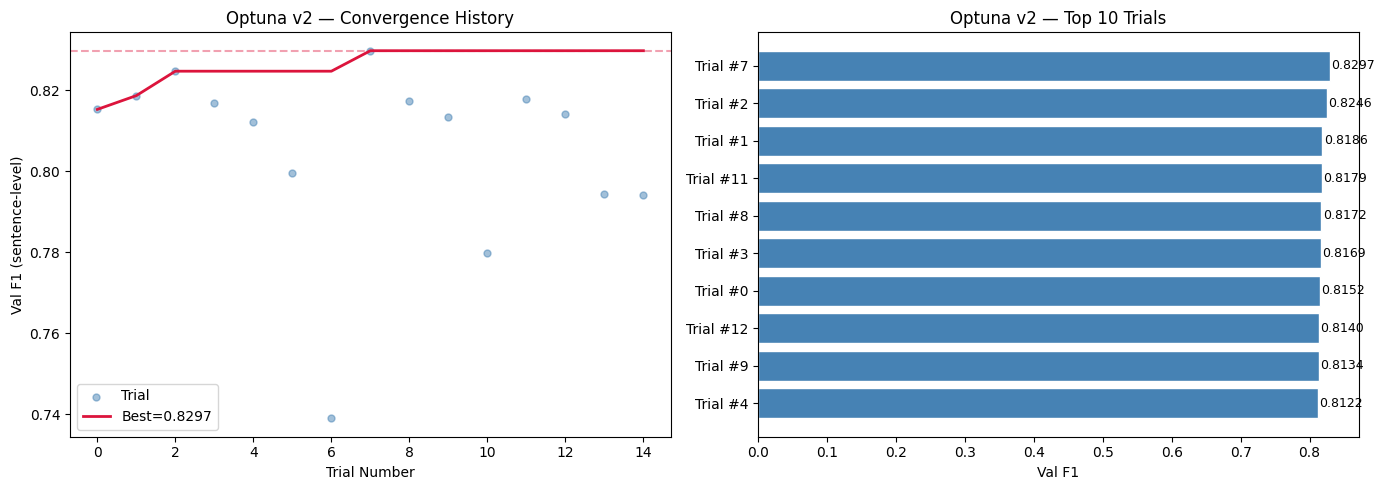

✅ Convergence plot saved → /content/drive/MyDrive/Colab Datasets/Results v2/optuna_convergence_v2.png


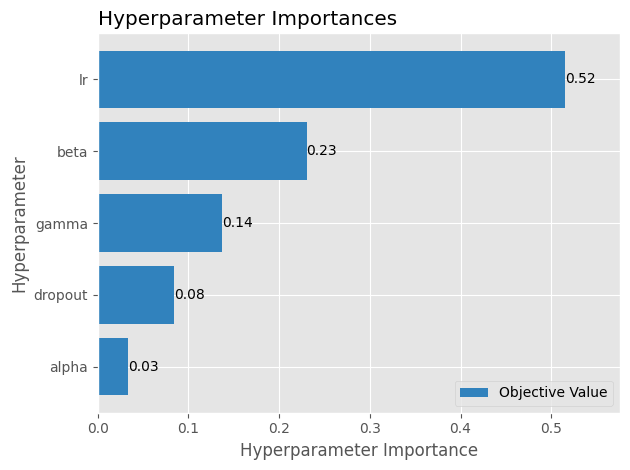

✅ Param importance plot saved → /content/drive/MyDrive/Colab Datasets/Results v2/optuna_param_importance_v2.png


In [ ]:
# ── Plot 1: Convergence + Top-10 ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence
ax1 = axes[0]
valid_trials  = [t for t in study.trials if t.value is not None]
trial_nos     = [t.number for t in valid_trials]
trial_vals    = [t.value  for t in valid_trials]
running_best  = []
cur_best      = 0.0
for v in trial_vals:
    cur_best = max(cur_best, v)
    running_best.append(cur_best)

ax1.scatter(trial_nos, trial_vals, alpha=0.5, s=25, color="steelblue", label="Trial")
ax1.plot(trial_nos, running_best, color="crimson", linewidth=2, label=f"Best={study.best_value:.4f}")
ax1.axhline(study.best_value, color="crimson", linestyle="--", alpha=0.4)
ax1.set_xlabel("Trial Number")
ax1.set_ylabel("Val F1 (sentence-level)")
ax1.set_title("Optuna v2 — Convergence History")
ax1.legend()

# Top-10 trials
ax2 = axes[1]
top10 = sorted(valid_trials, key=lambda t: t.value, reverse=True)[:10]
y_labels = [f"Trial #{t.number}" for t in top10]
y_vals   = [t.value for t in top10]
bars = ax2.barh(y_labels[::-1], y_vals[::-1], color="steelblue", edgecolor="white")
ax2.set_xlabel("Val F1")
ax2.set_title("Optuna v2 — Top 10 Trials")
for i, (bar, val) in enumerate(zip(bars, y_vals[::-1])):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
conv_path = f"{RESULT_DIR}/optuna_convergence_v2.png"
plt.savefig(conv_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Convergence plot saved → {conv_path}")

# ── Plot 2: Parameter Importance ──────────────────────────────────────────
try:
    fig2 = optuna.visualization.matplotlib.plot_param_importances(study)
    plt.tight_layout()
    imp_path = f"{RESULT_DIR}/optuna_param_importance_v2.png"
    plt.savefig(imp_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Param importance plot saved → {imp_path}")
except Exception as e:
    print(f"⚠️  Param importance plot gagal: {e}")
    # Fallback: bar chart manual
    try:
        importances = optuna.importance.get_param_importances(study)
        fig3, ax3 = plt.subplots(figsize=(8, 5))
        params_sorted = sorted(importances.items(), key=lambda x: x[1])
        ax3.barh([p for p, _ in params_sorted], [v for _, v in params_sorted], color="steelblue")
        ax3.set_xlabel("Importance")
        ax3.set_title("Optuna v2 — Parameter Importance (fallback)")
        plt.tight_layout()
        imp_path2 = f"{RESULT_DIR}/optuna_param_importance_v2_fallback.png"
        plt.savefig(imp_path2, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✅ Fallback importance plot saved → {imp_path2}")
    except Exception as e2:
        print(f"⚠️  Fallback plot juga gagal: {e2}")

## **Final Validation**

In [ ]:
print("=" * 60)
print("  VALIDASI AKHIR NB04v2")
print("=" * 60)

checks = {
    "optuna_best_params_v2.json": f"{RESULT_DIR}/optuna_best_params_v2.json",
    "optuna_study_v2.db"        : OPTUNA_DB_PATH,
    "optuna_convergence_v2.png" : f"{RESULT_DIR}/optuna_convergence_v2.png",
}

all_passed = True
for label, path in checks.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1024 if exists else 0
    print(f'  {"✅" if exists else "❌"} {label:<35} {f"({size:.1f} KB)" if exists else "— TIDAK ADA"}')
    if not exists:
        all_passed = False

print()
json_path = f"{RESULT_DIR}/optuna_best_params_v2.json"
if os.path.exists(json_path):
    with open(json_path) as f:
        bp = json.load(f)
    required_keys = [
        "alpha", "beta", "lr", "dropout", "gamma",
        "label_smoothing", "warmup_steps", "weight_decay", "batch_size"
    ]
    print("  Keys di optuna_best_params_v2.json:")
    for k in required_keys:
        present = k in bp
        print(f'    {"✅" if present else "❌"} {k}')
        if not present:
            all_passed = False

print()
val_harmonic_f1 = study.best_value
threshold = 0.87
f1_ok = val_harmonic_f1 >= threshold
print(f'  {"✅" if f1_ok else "⚠️ "} Best Harmonic(sent,span) = {val_harmonic_f1:.4f}  '
      f'(threshold >= {threshold})')
if not f1_ok:
    print("     → Jika jauh di bawah 0.87, cek: BIO data dari BIO Splits v2, kualitas CRF, dan search space.")

# Summary
print()
print("=" * 60)
if all_passed:
    print("✅ Semua validasi PASSED. NB04v2 selesai!")
    print()
    print("LANGKAH SELANJUTNYA:")
    print("  1. Salin BEST_PARAMS (lihat cell 15) ke NB03v2")
    print("  2. Jalankan NB03v2 untuk training model final")
    print("  3. Output NB04v2 tersimpan di:", RESULT_DIR)
else:
    print("❌ Ada validasi yang GAGAL — periksa output di atas.")
print("=" * 60)

  VALIDASI AKHIR NB04v2
  ✅ optuna_best_params_v2.json          (0.2 KB)
  ✅ optuna_study_v2.db                  (124.0 KB)
  ✅ optuna_convergence_v2.png           (85.8 KB)

  Keys di optuna_best_params_v2.json:
    ✅ alpha
    ✅ beta
    ✅ lr
    ✅ dropout
    ✅ gamma
    ✅ label_smoothing
    ✅ warmup_steps
    ✅ weight_decay
    ✅ batch_size

  ⚠️  Best Harmonic(sent,span) = 0.8297  (threshold >= 0.87)
     → Jika jauh di bawah 0.87, cek: BIO data dari BIO Splits v2, kualitas CRF, dan search space.

✅ Semua validasi PASSED. NB04v2 selesai!

LANGKAH SELANJUTNYA:
  1. Salin BEST_PARAMS (lihat cell 15) ke NB03v2
  2. Jalankan NB03v2 untuk training model final
  3. Output NB04v2 tersimpan di: /content/drive/MyDrive/Colab Datasets/Results v2
